# Retrieval Query Strategy Comparison (Qdrant)

This notebook evaluates three retrieval query strategies over 10 random samples from `evaluation.json` using Qdrant at `localhost:6333`.

Strategies:
- Regex/string-based (helper functions) intelligent query generation.

In [1]:
import json
import random
import re
from pathlib import Path


import pandas as pd
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client import models

RANDOM_SEED = 42
SAMPLE_SIZE = 10
TOP_K = 7
COLLECTION_NAME = "guideline_embeddings"
MODEL_NAME = "BAAI/bge-large-en-v1.5"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EVAL_PATH = DATA_DIR / "evaluation.json"
EVAL_FILES_DIR = DATA_DIR / "evaluation_files"

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation file: {EVAL_PATH}")

c:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project
Evaluation file: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation.json


In [16]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from data_processing.indent_signal import check_indent_errors
from data_processing.mutable_default_signal import check_mutable_default_errors
from data_processing.naming_signal import check_naming_convention_errors
from data_processing.documentation_signal import check_documentation_formatting_errors
from data_processing.unused_import_signal import check_unused_import_errors

In [3]:
# Load evaluation data and select SAMPLE_SIZE random samples
with EVAL_PATH.open("r", encoding="utf-8") as f:
    evaluation_data = json.load(f)

random.seed(RANDOM_SEED)
sampled_entries = random.sample(evaluation_data, k=min(SAMPLE_SIZE, len(evaluation_data)))

def resolve_source_file(entry):
    source_path = Path(entry["source_file"])
    if source_path.is_absolute():
        return source_path
    return EVAL_FILES_DIR / source_path.name if not (EVAL_FILES_DIR / source_path).exists() else EVAL_FILES_DIR / source_path

for entry in sampled_entries:
    file_path = resolve_source_file(entry)
    entry["resolved_source_file"] = str(file_path)
    entry["file_text"] = file_path.read_text(encoding="utf-8", errors="ignore")

print(f"Loaded {len(evaluation_data)} total entries")
print(f"Sampled {len(sampled_entries)} entries")
pd.DataFrame([
    {
        "id": e["id"],
        "repo": e["repo"],
        "source_path": e["source_path"],
        "resolved_source_file": e["resolved_source_file"]
    }
    for e in sampled_entries
])

Loaded 97 total entries
Sampled 10 entries


,id,repo,source_path,resolved_source_file
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
1,synthetic-django_PR_36,kannan-dedsec/synthetic-django,urls.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
2,synthetic-django_PR_24,kannan-dedsec/synthetic-django,managers.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
3,synthetic-sklearn_PR_38,kannan-dedsec/synthetic-sklearn,tests/test_models.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
4,synthetic-fastapi_PR_38,kannan-dedsec/synthetic-fastapi,tests/test_users.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
5,synthetic-fastapi_PR_34,kannan-dedsec/synthetic-fastapi,schemas/item.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
6,synthetic-fastapi_PR_31,kannan-dedsec/synthetic-fastapi,routers/auth.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
7,synthetic-django_PR_39,kannan-dedsec/synthetic-django,views.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
8,synthetic-django_PR_35,kannan-dedsec/synthetic-django,tests/test_views.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
9,synthetic-sklearn_PR_30,kannan-dedsec/synthetic-sklearn,hyperparameter_tuning.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...


In [4]:
# Connect to Qdrant and load embedding model
client = QdrantClient(url="http://localhost:6333")
collection_info = client.get_collection(COLLECTION_NAME)
print(f"Connected to Qdrant. Collection: {COLLECTION_NAME}")
print(f"Points count: {collection_info.points_count}")

model = SentenceTransformer(MODEL_NAME)
print(f"Loaded model: {MODEL_NAME}")

Connected to Qdrant. Collection: guideline_embeddings
Points count: 505


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1688.08it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: BAAI/bge-large-en-v1.5


In [5]:
COMMON_SOURCE_TYPES = ["pep8", "flake8", "pylint", "ruff", "pep257"]

def repo_family(repo_name):
    repo_lower = repo_name.lower()
    for family in ["django", "fastapi", "flask", "pandas", "sklearn", "scikit-learn"]:
        if family in repo_lower:
            return "scikit-learn" if family == "sklearn" else family
    return None

def build_query_filter(repo_name):
    family = repo_family(repo_name)
    should_conditions = [
        models.FieldCondition(key="source_type", match=models.MatchValue(value=s))
        for s in COMMON_SOURCE_TYPES
    ]
    if family:
        should_conditions.insert(
            0,
            models.FieldCondition(
                key="source_type",
                match=models.MatchValue(value=f"{family}_guidelines"),
            ),
        )
        should_conditions.insert(
            1,
            models.FieldCondition(
                key="source_type",
                match=models.MatchValue(value=f"{family}_review_comment"),
            ),
        )
    return models.Filter(should=should_conditions)

def retrieve_guidelines(query_text, repo_name, top_k=TOP_K):
    query_vector = model.encode(query_text).tolist()
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        query_filter=build_query_filter(repo_name),
        limit=top_k,
    )
    return response.points

print("Retrieval helpers ready")

Retrieval helpers ready


In [22]:
# Strategy 2: Regex/string-based intelligent query with helper-based static signals
def query_strategy(entry):
    file_path = entry["resolved_source_file"]

    indent_issues = check_indent_errors(file_path)
    mutable_default_issues = check_mutable_default_errors(file_path)
    naming_issues = check_naming_convention_errors(file_path)
    documentation_issues = check_documentation_formatting_errors(file_path)
    unused_import_issues = check_unused_import_errors(file_path)
    
    signals = []

    #  Naming (USE ACTUAL ERRORS)
    if naming_issues:
        examples = " ".join(naming_issues[:3])
        signals.append(f"Naming issues detected: {examples}")

    #  Indentation (USE ACTUAL ERRORS)
    if indent_issues:
        examples = " ".join(indent_issues[:3])
        signals.append(f"Indentation problems detected: {examples}")

    #  Mutable defaults (USE ACTUAL ERRORS)
    if mutable_default_issues:
        examples = " ".join(mutable_default_issues[:2])
        signals.append(f"Mutable default argument issues: {examples}")

    #  Documentation (USE ACTUAL ERRORS)
    if documentation_issues:
        examples = " ".join(documentation_issues[:3])
        signals.append(f"Documentation formatting issues: {examples}")

    #  Unused imports (USE ACTUAL ERRORS)
    if unused_import_issues:
        examples = " ".join(unused_import_issues[:3])
        signals.append(f"Unused import issues: {examples}")

    return " ".join(signals)

print("Strategy 2 query builder ready")

Strategy 2 query builder ready


In [23]:
# Run strategy 2 over sampled entries and collect retrieved chunks with timing
import time

chunk_rows = []
for entry in sampled_entries:
    try:
        query_text = query_strategy(entry)
    except Exception as e:
        query_text = f"<error building query: {e}>"

    start = time.perf_counter()
    try:
        points = retrieve_guidelines(query_text, entry.get('repo', ''), top_k=TOP_K)
    except Exception as e:
        points = []
    end = time.perf_counter()

    retrieval_time = end - start

    # Safely extract payload representations for storage
    payloads = []
    for p in points:
        try:
            payload = getattr(p, 'payload', p)
        except Exception:
            payload = p
        payloads.append(str(payload))

    if payloads:
        per_chunk_time = retrieval_time / max(1, len(payloads))
        for idx, payload in enumerate(payloads):
            chunk_rows.append({
                'id': entry.get('id'),
                'repo': entry.get('repo'),
                'source_path': entry.get('source_path'),
                'resolved_source_file': entry.get('resolved_source_file'),
                'query': query_text,
                'retrieved_count': len(payloads),
                'chunk_index': idx,
                'retrieved_payload': payload,
                'retrieval_time': retrieval_time,
                'time_taken': per_chunk_time,
            })
    else:
        # No points returned; record a single row with empty payload and the retrieval time
        chunk_rows.append({
            'id': entry.get('id'),
            'repo': entry.get('repo'),
            'source_path': entry.get('source_path'),
            'resolved_source_file': entry.get('resolved_source_file'),
            'query': query_text,
            'retrieved_count': 0,
            'chunk_index': None,
            'retrieved_payload': None,
            'retrieval_time': retrieval_time,
            'time_taken': retrieval_time,
        })

results_df = pd.DataFrame(chunk_rows)
results_df.head()

,id,repo,source_path,resolved_source_file,query,retrieved_count,chunk_index,retrieved_payload,retrieval_time,time_taken
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,0,{'text': 'N803: Argument name should be lowerc...,6.020476,0.860068
1,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,1,{'text': 'N802: Function name should be lowerc...,6.020476,0.860068
2,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,2,{'text': 'B006: Mutable default arguments caus...,6.020476,0.860068
3,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,3,{'text': 'N816: Variable in global scope shoul...,6.020476,0.860068
4,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,4,"{'text': 'Python packages should have short, a...",6.020476,0.860068


In [19]:
# Aggregate results by PR and show ground-truth violations with retrieved chunks
# Load ground_truth_reviews directly from evaluation.json
with open(EVAL_PATH, 'r', encoding='utf-8') as f:
    full_eval = json.load(f)

print(f"Loaded full evaluation data for ground truth mapping: {len(full_eval)} entries")
for i in range(3):
    print(f"Sample entry {i}: ID={full_eval[i].get('id')}, GT Violations={full_eval[i].get('ground_truth_reviews')}")
gt_map = {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}

Loaded full evaluation data for ground truth mapping: 97 entries
Sample entry 0: ID=synthetic-django_PR_21, GT Violations=[{'line_number': 9, 'violation_category': 'unused_import', 'review_comment': 'Unused import: os'}, {'line_number': 10, 'violation_category': 'unused_import', 'review_comment': 'Unused import: sys'}, {'line_number': 11, 'violation_category': 'unused_import', 'review_comment': 'Unused import: re'}]
Sample entry 1: ID=synthetic-django_PR_22, GT Violations=[{'line_number': 43, 'violation_category': 'naming_convention', 'review_comment': 'camelCase function name: cleanTitle'}, {'line_number': 76, 'violation_category': 'naming_convention', 'review_comment': 'camelCase function name: cleanName'}]
Sample entry 2: ID=synthetic-django_PR_23, GT Violations=[{'line_number': 11, 'violation_category': 'unused_import', 'review_comment': 'Unused import: os'}, {'line_number': 12, 'violation_category': 'unused_import', 'review_comment': 'Unused import: sys'}, {'line_number': 13, 'vio

In [24]:
results_df['query'].head(10)

0    Naming issues detected: Line 27: Argument name...
1    Naming issues detected: Line 27: Argument name...
2    Naming issues detected: Line 27: Argument name...
3    Naming issues detected: Line 27: Argument name...
4    Naming issues detected: Line 27: Argument name...
5    Naming issues detected: Line 27: Argument name...
6    Naming issues detected: Line 27: Argument name...
7    Indentation problems detected: Line 17: Indent...
8    Indentation problems detected: Line 17: Indent...
9    Indentation problems detected: Line 17: Indent...
Name: query, dtype: str

In [25]:
# PR-level metric printout (restored)
import ast
import json
from pathlib import Path

def load_ground_truth_map(eval_path, fallback_entries):
    try:
        with open(eval_path, 'r', encoding='utf-8') as f:
            full_eval = json.load(f)
        return {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}
    except Exception:
        return {e.get('id'): e.get('ground_truth_reviews') for e in fallback_entries}

def normalize_label(x):
    if x is None:
        return None
    return str(x).strip().lower().replace('-', '_').replace(' ', '_')

def normalize_gt_categories(gt_list, allowed=None):
    cats = set()
    for gt in gt_list or []:
        if isinstance(gt, dict):
            c = normalize_label(gt.get('violation_category'))
        else:
            c = normalize_label(gt)
        if c:
            if allowed is None or c in allowed:
                cats.add(c)
    return sorted(cats)

def extract_payload_category(payload):
    if payload is None:
        return None

    if isinstance(payload, dict):
        obj = payload
    else:
        text = str(payload)
        obj = None
        try:
            maybe = ast.literal_eval(text)
            if isinstance(maybe, dict):
                obj = maybe
        except Exception:
            obj = None

        if obj is None:
            m = re.search(r"(?:violation_category|category)['\"]?\s*[:=]\s*['\"]([a-zA-Z_\- ]+)['\"]", text)
            if m:
                return normalize_label(m.group(1))

    if obj is not None:
        for key in ['violation_category', 'category', 'label', 'violation']:
            val = obj.get(key) if isinstance(obj, dict) else None
            if isinstance(val, str) and val.strip():
                return normalize_label(val)
    return None

def ranked_chunk_categories_for_pr(results, pr_id, max_k):
    rows = results[results['id'] == pr_id]
    rows = rows[rows['retrieved_payload'].notnull()].copy()
    if rows.empty:
        return []
    rows = rows.sort_values(by='chunk_index', na_position='last').head(max_k)
    return [extract_payload_category(p) for p in rows['retrieved_payload'].tolist()]

def pr_level_metrics(gt_categories, retrieved_categories, k):
    gt_set = set(gt_categories)
    topk = [c for c in retrieved_categories[:k] if c]

    gt_den = min(5, len(gt_set))
    if gt_den == 0:
        return 0.0, 0.0, 0.0

    matched_gt = {c for c in gt_set if c in topk}
    recall_at_k = len(matched_gt) / gt_den

    precision_at_k = (sum(1 for c in topk if c in gt_set) / len(topk)) if topk else 0.0

    rr_values = []
    for gt_c in gt_set:
        rr = 0.0
        for rank, c in enumerate(topk, start=1):
            if c == gt_c:
                rr = 1.0 / rank
                break
        rr_values.append(rr)
    mrr_at_k = sum(rr_values) / len(rr_values) if rr_values else 0.0

    return recall_at_k, precision_at_k, mrr_at_k

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path('..').resolve()
if 'EVAL_PATH' not in globals():
    EVAL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'evaluation.json'
if 'sampled_entries' not in globals():
    sampled_entries = []
if 'results_df' not in globals():
    raise ValueError('results_df is not defined. Run the retrieval cell first.')

allowed = None
if 'GROUPED_VIOLATION_CATEGORIES' in globals():
    allowed = {normalize_label(c) for c in GROUPED_VIOLATION_CATEGORIES}

k_values = sorted(set(k_values)) if 'k_values' in globals() else [1, 3, 5, 7]
max_k = max(k_values)

gt_map_list = load_ground_truth_map(EVAL_PATH, sampled_entries)
grouped = (
    results_df.groupby('id')
    .agg(
        repo=('repo', 'first'),
        resolved_source_file=('resolved_source_file', 'first')
    )
    .reset_index()
)

for _, row in grouped.iterrows():
    pid = row['id']
    gt_categories = normalize_gt_categories(gt_map_list.get(pid) or [], allowed=allowed)
    retrieved_categories = ranked_chunk_categories_for_pr(results_df, pid, max_k)

    print(f"ID: {pid} | repo: {row['repo']} | resolved: {row['resolved_source_file']}")
    print(f"  GT categories (unique): {gt_categories if gt_categories else 'None'}")
    print(f"  Retrieved categories (ranked up to max K): {retrieved_categories}")

    if not gt_categories:
        print('  No GT categories to compute PR-level metrics for.')
        print('---')
        continue

    for k in k_values:
        r_k, p_k, mrr_k = pr_level_metrics(gt_categories, retrieved_categories, k)
        print(
            f"  PR Metrics @K={k}: Recall={r_k:.3f} | "
            f"Precision={p_k:.3f} | Modified_MRR={mrr_k:.3f}"
        )

    print('---')

ID: synthetic-django_PR_24 | repo: kannan-dedsec/synthetic-django | resolved: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation_files\synthetic-django_PR_24_managers.py
  GT categories (unique): ['mutable_default', 'naming_convention']
  Retrieved categories (ranked up to max K): ['naming_convention', 'naming_convention', 'naming_convention', 'naming_convention', 'naming_convention', 'naming_convention', 'naming_convention']
  PR Metrics @K=1: Recall=0.500 | Precision=1.000 | Modified_MRR=0.500
  PR Metrics @K=3: Recall=0.500 | Precision=1.000 | Modified_MRR=0.500
  PR Metrics @K=5: Recall=0.500 | Precision=1.000 | Modified_MRR=0.500
  PR Metrics @K=7: Recall=0.500 | Precision=1.000 | Modified_MRR=0.500
---
ID: synthetic-django_PR_35 | repo: kannan-dedsec/synthetic-django | resolved: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation_files\synthetic-django_PR_35_tests_test_views.py
  GT categories 

,k,cumulative_recall_at_k,cumulative_precision_at_k,cumulative_mrr_at_k
0,1,0.358333,0.6,0.358333
1,3,0.416667,0.6,0.381944
2,5,0.466667,0.6,0.394444
3,7,0.516667,0.6,0.402778


,k,category,category_recall_contribution
0,1,documentation_formatting,0.000000
1,1,indentation,1.000000
2,1,mutable_default,0.000000
3,1,naming_convention,0.666667
4,1,unused_import,0.166667
5,3,documentation_formatting,0.000000
6,3,indentation,1.000000
7,3,mutable_default,0.250000
8,3,naming_convention,0.833333
9,3,unused_import,0.166667


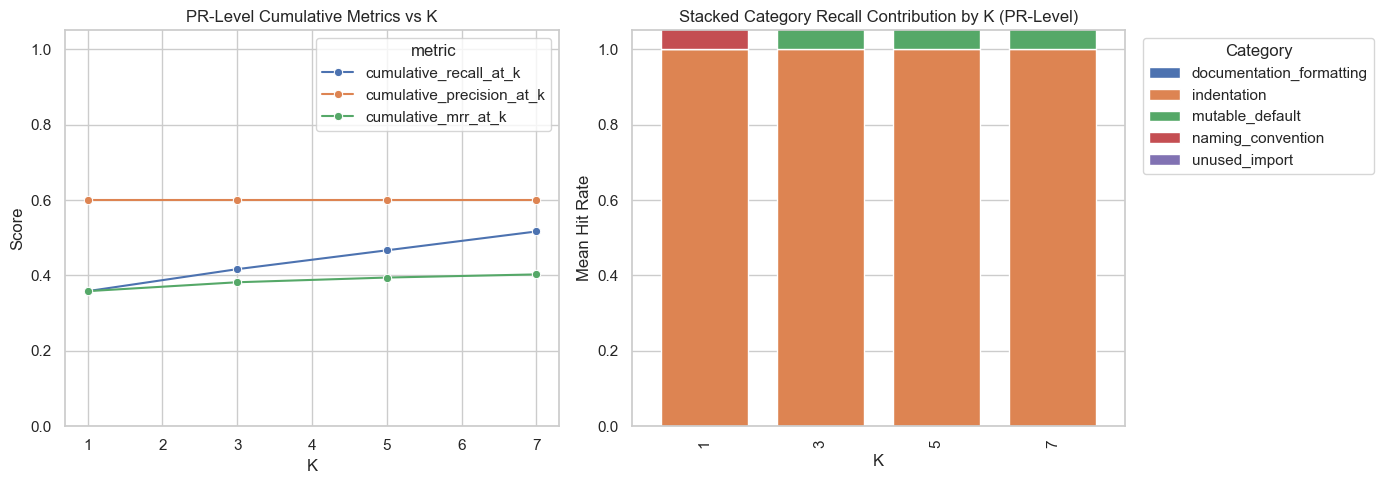

Evaluated 10 PRs for K values: [1, 3, 5, 7]
Metric definitions are PR-level and category-coverage based (as requested).


In [26]:
# PR-level retrieval metrics across multiple K values (custom formulas)
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Edit this list to test any K values you want
k_values = [1, 3, 5, 7]

# Fixed category universe used in this project
GROUPED_VIOLATION_CATEGORIES = [
    'naming_convention',
    'unused_import',
    'indentation',
    'mutable_default',
    'documentation_formatting',
]

def load_ground_truth_map(eval_path, fallback_entries):
    try:
        with open(eval_path, 'r', encoding='utf-8') as f:
            full_eval = json.load(f)
        return {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}
    except Exception:
        return {e.get('id'): e.get('ground_truth_reviews') for e in fallback_entries}

def normalize_gt_categories(gt_list):
    categories = []
    for gt in gt_list or []:
        if isinstance(gt, dict):
            cat = (gt.get('violation_category') or 'unknown').strip()
        else:
            cat = str(gt).strip()
        if cat in GROUPED_VIOLATION_CATEGORIES:
            categories.append(cat)
    return sorted(set(categories))

def extract_payload_category(payload):
    """Best-effort extraction of category/violation category from stringified payload."""
    if payload is None:
        return None
    if isinstance(payload, dict):
        obj = payload
    else:
        text = str(payload)
        obj = None
        # Try Python-literal dict first (payloads were stored via str(dict))
        try:
            maybe = ast.literal_eval(text)
            if isinstance(maybe, dict):
                obj = maybe
        except Exception:
            obj = None
        # Fallback: simple regex over string representation
        if obj is None:
            m = re.search(r"(?:violation_category|category)['\"]?\s*[:=]\s*['\"]([a-zA-Z_\-]+)['\"]", text)
            if m:
                return m.group(1).strip()

    if obj is not None:
        for key in ['violation_category', 'category', 'label', 'violation']:
            val = obj.get(key) if isinstance(obj, dict) else None
            if isinstance(val, str) and val.strip():
                return val.strip()
    return None

def ranked_chunk_categories_for_pr(results, pr_id, max_k):
    rows = results[results['id'] == pr_id]
    rows = rows[rows['retrieved_payload'].notnull()].copy()
    if rows.empty:
        return []
    rows = rows.sort_values(by='chunk_index', na_position='last')
    rows = rows.head(max_k)
    out = []
    for p in rows['retrieved_payload'].tolist():
        c = extract_payload_category(p)
        out.append(c)
    return out

def pr_level_metrics(gt_categories, retrieved_categories, k):
    """
    Custom PR-level metrics requested by user.

    Recall@K = matched GT categories / unique GT categories (max 5)
      where a GT category is matched if it appears at least once in Top-K retrieved chunk categories.

    Precision@K = (# retrieved chunks in Top-K whose category is in GT categories) / (# chunks in Top-K)

    MRR@K (modified) = mean over GT categories of reciprocal rank of first match in Top-K.
      For each GT category c: RR_c = 1/rank(first c in Top-K), else 0.
    """
    gt_set = set(gt_categories)
    topk = retrieved_categories[:k]
    topk_non_null = [c for c in topk if c]

    gt_den = min(5, len(gt_set))
    if gt_den == 0:
        return 0.0, 0.0, 0.0

    matched_gt = {c for c in gt_set if c in topk_non_null}
    recall_at_k = len(matched_gt) / gt_den

    if len(topk_non_null) == 0:
        precision_at_k = 0.0
    else:
        precision_at_k = sum(1 for c in topk_non_null if c in gt_set) / len(topk_non_null)

    rr_values = []
    for gt_c in gt_set:
        rr = 0.0
        for rank, c in enumerate(topk_non_null, start=1):
            if c == gt_c:
                rr = 1.0 / rank
                break
        rr_values.append(rr)
    mrr_at_k = sum(rr_values) / len(rr_values) if rr_values else 0.0

    return recall_at_k, precision_at_k, mrr_at_k

gt_map_list = load_ground_truth_map(EVAL_PATH, sampled_entries)

grouped = (
    results_df.groupby('id')
    .agg(
        repo=('repo', 'first'),
        resolved_source_file=('resolved_source_file', 'first')
    )
    .reset_index()
)

k_values = sorted(set(k_values))
max_k = max(k_values)

pr_units = []
for _, row in grouped.iterrows():
    pid = row['id']
    gt_categories = normalize_gt_categories(gt_map_list.get(pid) or [])
    retrieved_categories = ranked_chunk_categories_for_pr(results_df, pid, max_k)
    if gt_categories:
        pr_units.append({
            'id': pid,
            'repo': row['repo'],
            'gt_categories': gt_categories,
            'retrieved_categories': retrieved_categories,
        })

if not pr_units:
    raise ValueError('No PR units with valid ground-truth categories were found.')

records = []
for k in k_values:
    for u in pr_units:
        r_k, p_k, mrr_k = pr_level_metrics(u['gt_categories'], u['retrieved_categories'], k)
        records.append({
            'k': k,
            'id': u['id'],
            'repo': u['repo'],
            'recall_at_k': r_k,
            'precision_at_k': p_k,
            'mrr_at_k': mrr_k,
            'gt_category_count': len(u['gt_categories']),
        })

metrics_long_df = pd.DataFrame(records)
overall_metrics_df = (
    metrics_long_df.groupby('k', as_index=False)[['recall_at_k', 'precision_at_k', 'mrr_at_k']].mean()
    .rename(columns={
        'recall_at_k': 'cumulative_recall_at_k',
        'precision_at_k': 'cumulative_precision_at_k',
        'mrr_at_k': 'cumulative_mrr_at_k',
    })
)

# Category-level recall contribution for stacked bar
category_records = []
for k in k_values:
    for u in pr_units:
        topk = [c for c in u['retrieved_categories'][:k] if c]
        topk_set = set(topk)
        for cat in GROUPED_VIOLATION_CATEGORIES:
            if cat in u['gt_categories']:
                category_records.append({
                    'k': k,
                    'id': u['id'],
                    'category': cat,
                    'hit': 1 if cat in topk_set else 0,
                })

category_metrics_df = pd.DataFrame(category_records)
if not category_metrics_df.empty:
    category_metrics_df = (
        category_metrics_df.groupby(['k', 'category'], as_index=False)['hit'].mean()
        .rename(columns={'hit': 'category_recall_contribution'})
    )

display(overall_metrics_df)
if not category_metrics_df.empty:
    display(category_metrics_df.head(30))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall_plot_df = overall_metrics_df.melt(
    id_vars='k',
    value_vars=['cumulative_recall_at_k', 'cumulative_precision_at_k', 'cumulative_mrr_at_k'],
    var_name='metric',
    value_name='value',
)
sns.lineplot(data=overall_plot_df, x='k', y='value', hue='metric', marker='o', ax=axes[0])
axes[0].set_title('PR-Level Cumulative Metrics vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)

if not category_metrics_df.empty:
    pivot_contrib = (
        category_metrics_df.pivot(index='k', columns='category', values='category_recall_contribution')
        .fillna(0)
        .sort_index()
    )
    pivot_contrib.plot(kind='bar', stacked=True, ax=axes[1], width=0.75)
    axes[1].set_title('Stacked Category Recall Contribution by K (PR-Level)')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Mean Hit Rate')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    axes[1].axis('off')
    axes[1].text(0.05, 0.5, 'No category contribution data available', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Evaluated {len(pr_units)} PRs for K values: {k_values}")
print('Metric definitions are PR-level and category-coverage based (as requested).')

In [11]:
# temp save for results_df.to_csv("retrieval_strategy_2_results.csv", index=False)
results_df.to_csv("retrieval_strategy_2_results_v2.csv", index=False)